# **LOAN APPROVAL PROJECT**

## **I. TỔNG QUAN DỮ LIỆU LOAN APPROVAL (US & CANADA)**

Bộ dữ liệu Loan Approval bao gồm **50.000 bản ghi** hoàn chỉnh (không có giá trị trống), mô phỏng chính xác quy trình thẩm định tín dụng tại Bắc Mỹ. Dữ liệu được cấu trúc thành 4 nhóm cột rõ rệt:

- **Thông tin cá nhân:** Tuổi, nghề nghiệp và thâm niên làm việc.
- **Năng lực tài chính:** Thu nhập, tài sản và các tỷ lệ nợ quan trọng ($DTI$, $PTI$).
- **Lịch sử tín dụng:** Điểm tín dụng, lịch sử nợ xấu và các dấu hiệu vi phạm.
- **Chi tiết khoản vay:** Số tiền, mục đích và thời hạn vay.

Nhóm quyết định lựa chọn bộ dữ liệu vì:
- **Độ tin cậy chuyên môn:** Được xây dựng bởi chuyên gia dựa trên tiêu chuẩn ngân hàng thực tế tại Mỹ và Canada, đảm bảo tính logic giữa các biến số.
- **Dữ liệu chất lượng cao:** Quy mô mẫu lớn (50.000 dòng) và hoàn toàn sạch (không có giá trị Null), giúp tối ưu hóa thời gian xây dựng mô hình.
- **Tính thực tiễn:** Tài chính là một lĩnh vực đặc thù; việc phân tích bộ dữ liệu này giúp tiếp cận trực tiếp với bài toán dự báo rủi ro tín dụng thực tế.

## **II. Câu hỏi nghiên cứu và định hướng triển khai**

Mục tiêu cốt lõi của dự án là **xác định các yếu tố then chốt quyết định khả năng phê duyệt khoản vay**, từ đó đưa ra **chiến lược tập trung phân khúc khách hàng** nhằm tối ưu hóa lợi nhuận và giảm thiểu rủi ro tín dụng.

### **2.1. Các câu hỏi nghiên cứu trọng tâm**
Để giải quyết bài toán lớn, dự án tập trung trả lời ba câu hỏi cụ thể sau:
- **Q1: Nhóm khách hàng nào có mức độ rủi ro tín dụng cao nhất và đặc điểm nhận diện của họ là gì?** với mục tiêu chính nhằm phác họa chân dung khách hàng và phân đoạn thị trường để nhận diện sớm các nhóm đối tượng tiềm ẩn nợ xấu.
- **Q3: Tỷ lệ phê duyệt sẽ biến động như thế nào trước các kịch bản tiêu cực của nền kinh tế?** nhằm đánh giá sức chịu đựng của danh mục cho vay khi thu nhập khách hàng giảm hoặc nghĩa vụ nợ tăng
- **Q3: Yếu tố nào có trọng số ảnh hưởng lớn nhất đến quyết định phê duyệt khoản vay?** để sử dụng các phương pháp định lượng để xác định biến số then chốt, giúp ngân hàng minh bạch hóa quy trình thẩm định.

### **2.2. Định hướng triển khai kỹ thuật**

In [1]:
# install missing packages before importing
%pip install matplotlib seaborn xgboost category_encoders

import xgboost as xgb
from xgboost import XGBClassifier

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from category_encoders import WOEEncoder
import math

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# NHẬP DỮ LIỆU
path = 'Loan_approval_data_2025.xlsx'
df = pd.read_excel(path)
df.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1237.000,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1565.000,0.522,1


#### **2.2.1. Data Preprocessing**

In [3]:
df = df.drop('customer_id',axis=1)
df_Q3 = df.copy() # dùng cho Question 3

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      50000 non-null  int64  
 1   occupation_status        50000 non-null  object 
 2   years_employed           50000 non-null  float64
 3   annual_income            50000 non-null  int64  
 4   credit_score             50000 non-null  int64  
 5   credit_history_years     50000 non-null  float64
 6   savings_assets           50000 non-null  int64  
 7   current_debt             50000 non-null  int64  
 8   defaults_on_file         50000 non-null  int64  
 9   delinquencies_last_2yrs  50000 non-null  int64  
 10  derogatory_marks         50000 non-null  int64  
 11  product_type             50000 non-null  object 
 12  loan_intent              50000 non-null  object 
 13  loan_amount              50000 non-null  int64  
 14  interest_rate         

**KIỂM TRA OUTLIERS**

In [7]:
# Nhóm A: Thông tin cá nhân (chỉ lấy biến số)
group_A_num = ['age', 'years_employed']

# Nhóm B: Tài chính hiện tại (Toàn bộ là biến số)
group_B_num = ['annual_income', 'savings_assets', 'current_debt', 
               'debt_to_income_ratio', 'payment_to_income_ratio', 'loan_to_income_ratio']

# Nhóm C: Lịch sử tín dụng (Bỏ defaults_on_file vì là 0/1)
group_C_num = ['credit_score', 'credit_history_years', 
               'delinquencies_last_2yrs', 'derogatory_marks']

# Nhóm D: Khoản vay (Chỉ lấy biến số)
group_D_num = ['loan_amount', 'interest_rate']

In [8]:
# 3. Hàm vẽ Boxplot tập trung vào việc phát hiện Outliers
def plot_group_boxplots(cols, title):
    n_cols = len(cols)
    plt.figure(figsize=(4 * n_cols, 5))
    for i, col in enumerate(cols):
        plt.subplot(1, n_cols, i + 1)
        sns.boxplot(y=df[col], color='#4e79a7', fliersize=5)
        plt.title(col, fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

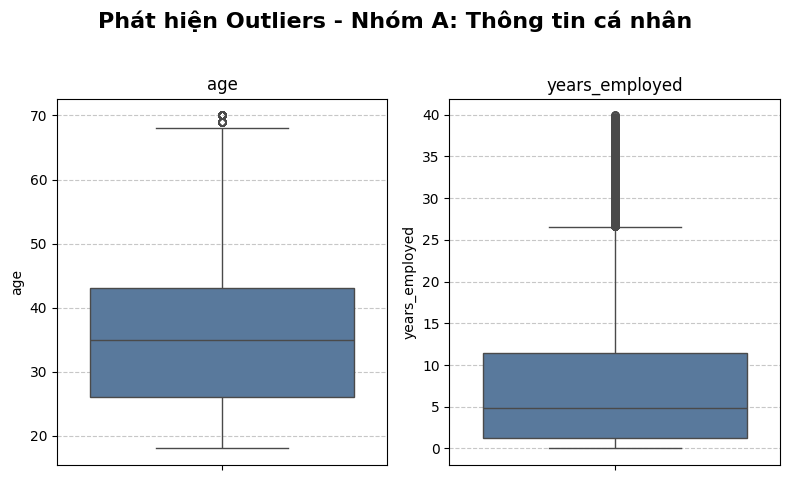

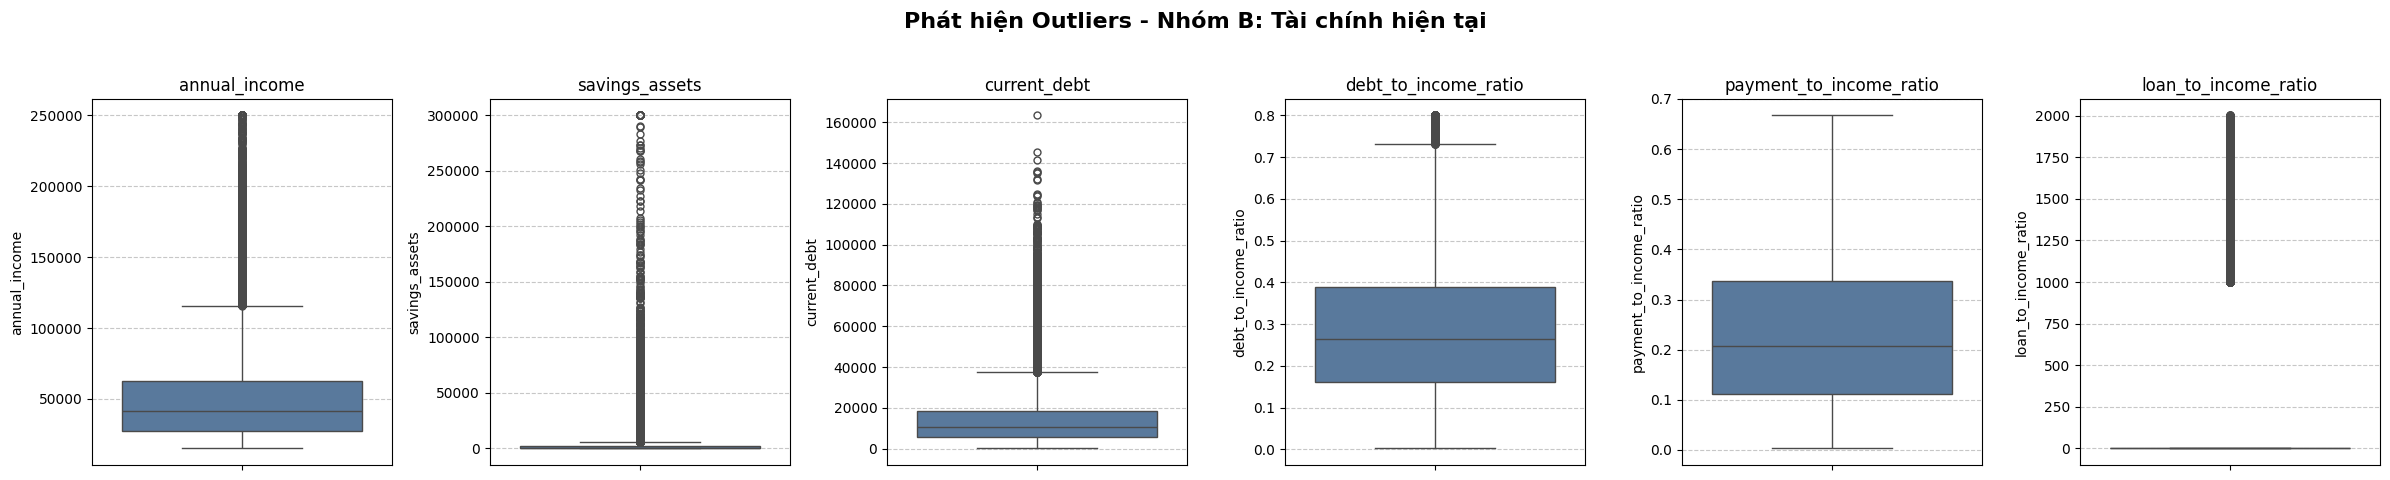

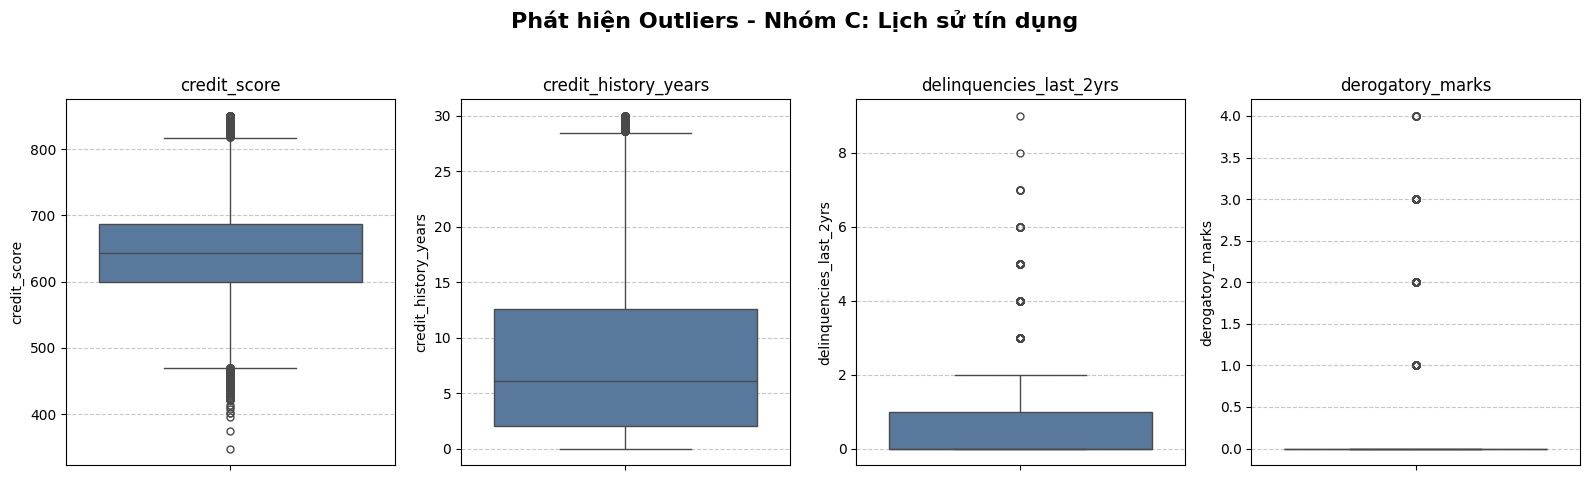

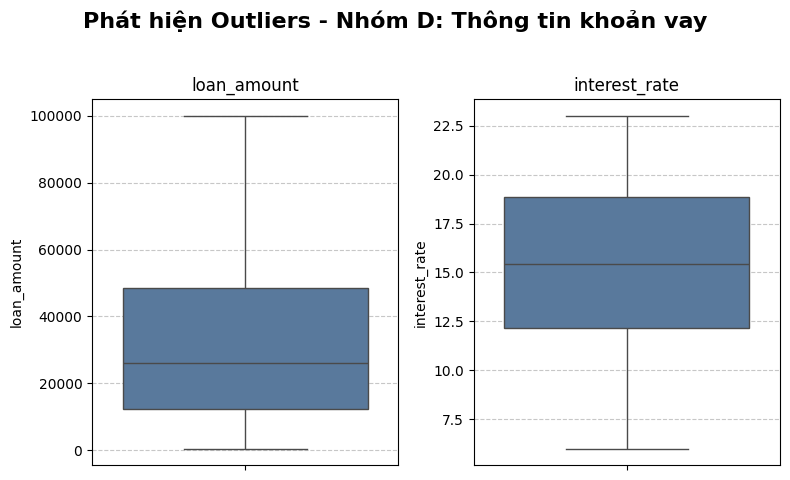

In [8]:
# 4. Vẽ cho từng nhóm
plot_group_boxplots(group_A_num, "Phát hiện Outliers - Nhóm A: Thông tin cá nhân")
plot_group_boxplots(group_B_num, "Phát hiện Outliers - Nhóm B: Tài chính hiện tại")
plot_group_boxplots(group_C_num, "Phát hiện Outliers - Nhóm C: Lịch sử tín dụng")
plot_group_boxplots(group_D_num, "Phát hiện Outliers - Nhóm D: Thông tin khoản vay")

-> Như vậy, các cột cần xử lý outliers là ```annual_income```, ```saving_assets```, ```current_debt```, ```loan_to_income_ratio```

**XỬ LÝ OUTLIERS**: sử dụng hàm **winsorize** và **log transform** để xử lý dữ liệu
- ```saving_assets```: do đây là một biến lệch rất nặng nên thực hiện log transform trước để co dữ liệu lại sau đó mới Winsorize nhẹ (1-99%) để loại bỏ nhiễu cực đoan
- ```current_debt, annual_income, loan_to_income_ratio```: thực hiện winsorize trước sau đó mới log transform

In [9]:
cols_to_process = ['savings_assets', 'current_debt', 'annual_income', 'loan_to_income_ratio']

# Flag Outlier trên dữ liệu GỐC ---
for col in cols_to_process:
    q_low = df[col].quantile(0.05)
    q_high = df[col].quantile(0.95)
    # Đánh dấu: 1 là outlier, 0 là bình thường
    df[col + '_outlier_flag'] = ((df[col] < q_low) | (df[col] > q_high)).astype(int)

In [10]:
# Định nghĩa hàm Winsorize ---
def winsorize_series(s, lower=0.05, upper=0.95):
    q_low = s.quantile(lower)
    q_high = s.quantile(upper)
    return s.clip(lower=q_low, upper=q_high)

In [11]:
# Xử lý đặc biệt cho 'savings_assets' ---
if 'savings_assets' in df.columns:
    # 1. Log transform trước
    df['savings_assets_log'] = np.log1p(df['savings_assets'])
    
    # 2. Winsorize trên dữ liệu đã Log 
    df['savings_assets_log'] = winsorize_series(df['savings_assets_log'], lower=0.01, upper=0.99)

In [12]:
# Xử lý các biến còn lại ---
other_cols = [c for c in cols_to_process if c != 'savings_assets']

for col in other_cols:
    # 1. Winsorize trước
    df[col] = winsorize_series(df[col], lower=0.05, upper=0.95)
    
    # 2. Log transform sau
    df[col + '_log'] = np.log1p(df[col])

**Thực hiện kiểm tra lại sau khi đã xử lý Outliers**

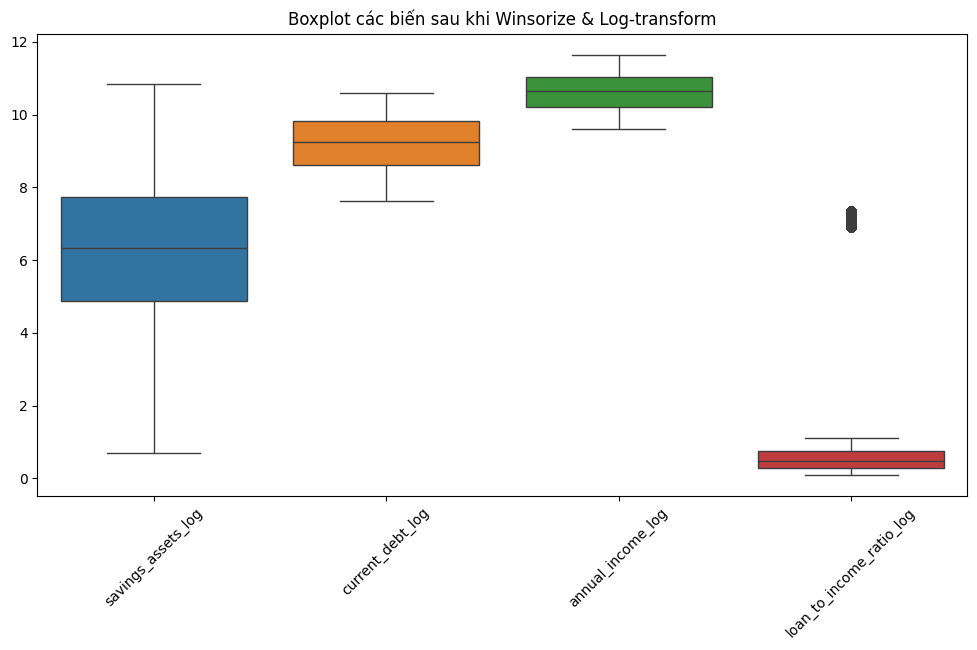

In [13]:
cols_plot = [
    'savings_assets_log',
    'current_debt_log',
    'annual_income_log',
    'loan_to_income_ratio_log'
]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_plot])
plt.title("Boxplot các biến sau khi Winsorize & Log-transform")
plt.xticks(rotation=45)
plt.show()

**Check banlace of target column**

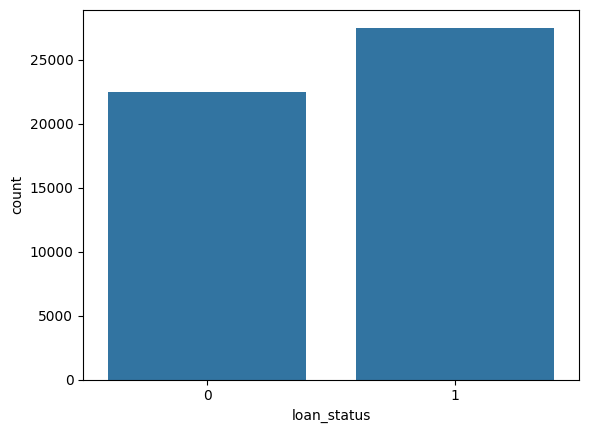

In [13]:
sns.countplot(data = df, x='loan_status') 
plt.show()

=> Như vậy, dữ liệu của target column - Loan Status tương đối cân bằng, không có hiện tượng lệch nhãn

#### **2.2.2. Exploratory Data Analysis**

**Kiểm tra tương quan của target column**

In [14]:
numeric_cols = [
    'age', 'years_employed', 
    'annual_income_log', 'savings_assets_log', 'current_debt_log',
    'debt_to_income_ratio', 'payment_to_income_ratio', 'loan_to_income_ratio_log',
    'credit_score', 'credit_history_years',
    'delinquencies_last_2yrs', 'derogatory_marks',
    'loan_amount', 'interest_rate', 'defaults_on_file',
    'loan_status'
]

numeric_df = df[numeric_cols]
corr_with_target = (numeric_df.corr()['loan_status'].drop('loan_status').sort_values(key=abs, ascending=False))
corr_with_target.to_frame()

,loan_status
credit_score,0.496316
delinquencies_last_2yrs,-0.318075
debt_to_income_ratio,-0.317363
age,0.311524
credit_history_years,0.277103
defaults_on_file,-0.263033
savings_assets_log,0.231340
derogatory_marks,-0.224735
years_employed,0.218875
payment_to_income_ratio,-0.193258


- Nhóm có tương quan mạnh: ```credit_score```, ```delinquencies_last_2yrs```, ```debt_to_income_ratio, age```
- Nhóm có tương quan vừa: ```credit_history_years```, ```defaults_on_file```, ```savings_assets_log```, ```derogatory_marks```, ```years_employed```
- Nhóm có tương quan yếu: ```payment_to_income_ratio```, ```interest_rate```, ```loan_to_income_ratio_log```, ```annual_income_log```, ```current_debt_log```, ```loan_amount```

**Kiểm tra tương quan giữa các biến feature với nhau**

In [15]:
feature_cols = [c for c in numeric_cols if c != 'loan_status']
X_df = numeric_df[feature_cols]
corr_X = X_df.corr()
def high_corr_pairs(corr_matrix, threshold=0.75):
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > threshold:
                high_corr.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_val
                ))
    return high_corr
high_corr = high_corr_pairs(corr_X, threshold=0.75)

print("Các cặp biến có tương quan cao (> 0.75):")
if len(high_corr) == 0:
    print("→ Không có cặp biến nào vượt ngưỡng.")
else:
    for a, b, v in high_corr:
        print(f"{a}  ↔  {b}  :  corr = {v:.3f}")

Các cặp biến có tương quan cao (> 0.75):
loan_to_income_ratio_log  ↔  payment_to_income_ratio  :  corr = 0.794


=> Như vậy, 2 biến ```loan_to_income_ratio_log``` và ```payment_to_income_ratio``` có tương quan với nhau khá cao cần cân nhắc trong quá trình sử dụng

#### **2.2.3. Modelling**

##### ***a. Câu hỏi nghiên cứu 1: Nhóm khách hàng nào đang có rủi ro tín dụng cao nhất và mang đặc điểm gì?***

**Lựa chọn biến feature**

In [16]:
selected_features = [
    'age', 'credit_score', 'credit_history_years', 'years_employed',
    'savings_assets_log', 'debt_to_income_ratio',
    'delinquencies_last_2yrs', 'defaults_on_file', 'derogatory_marks'
]

categorical = ['occupation_status', 'product_type', 'loan_intent']
numeric = selected_features

In [17]:
# --- BƯỚC 2: Train-Test Split ---
X_Q1 = df[numeric + categorical]
y_Q1 = df['loan_status']   # 1 = approved, 0 = rejected

X_trainQ1, X_testQ1, y_trainQ1, y_testQ1 = train_test_split(X_Q1, y_Q1, test_size=0.2, random_state=42, stratify=y_Q1)

In [18]:
# --- BƯỚC 3: WOE Encoding ---
woe = WOEEncoder(cols=categorical)

X_train_encoded = woe.fit_transform(X_trainQ1, y_trainQ1)
X_test_encoded = woe.transform(X_testQ1)
df_woe = woe.transform(X_Q1)

In [19]:
# --- BƯỚC 4: Train Logistic Model ---
model = LogisticRegression(max_iter=2000)
model.fit(X_train_encoded, y_trainQ1)
pred_test = model.predict_proba(X_test_encoded)[:, 1]
print("AUC on test:", roc_auc_score(y_testQ1, pred_test))

AUC on test: 0.9297810969701931


C:\Users\admin\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# --- BƯỚC 5: Tính Approval Probability cho toàn data ---
df['approval_prob'] = model.predict_proba(df_woe)[:, 1]

In [21]:
# --- BƯỚC 6: Phân nhóm  ---

df['approval_group'] = pd.qcut(
    df['approval_prob'], q=4,
    labels=['Low', 'Medium-Low', 'Medium', 'High'])

In [22]:
# --- BƯỚC 7: Profilling ---
profiling_vars = [
    'age', 'credit_score', 'credit_history_years', 'years_employed',
    'savings_assets_log', 'debt_to_income_ratio',
    'delinquencies_last_2yrs', 'defaults_on_file', 'derogatory_marks'
]

profile_table = df.groupby('approval_group')[profiling_vars].mean().round(3)
print("\n===== CUSTOMER APPROVAL PROFILING =====")
print(profile_table)

approval_rate = df.groupby('approval_group')['loan_status'].mean().round(3)
print("\n===== APPROVAL RATE BY GROUP =====")
print(approval_rate)


===== CUSTOMER APPROVAL PROFILING =====
                   age  credit_score  credit_history_years  years_employed  \
approval_group                                                               
Low             29.325       586.223                 5.102           4.798   
Medium-Low      32.386       626.982                 6.501           6.189   
Medium          36.168       658.545                 8.541           7.831   
High            41.949       702.710                12.529          11.001   

                savings_assets_log  debt_to_income_ratio  \
approval_group                                             
Low                          5.450                 0.373   
Medium-Low                   5.915                 0.314   
Medium                       6.451                 0.259   
High                         7.191                 0.197   

                delinquencies_last_2yrs  defaults_on_file  derogatory_marks  
approval_group                                     

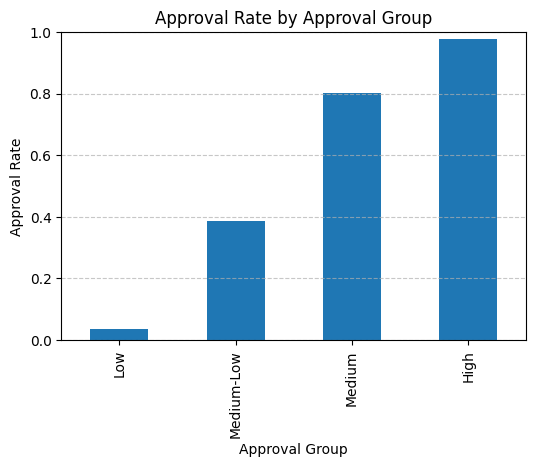

In [23]:
approval_rate = df.groupby('approval_group')['loan_status'].mean()

approval_rate.plot(kind='bar', figsize=(6,4))
plt.ylabel("Approval Rate")
plt.xlabel("Approval Group")
plt.title("Approval Rate by Approval Group")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

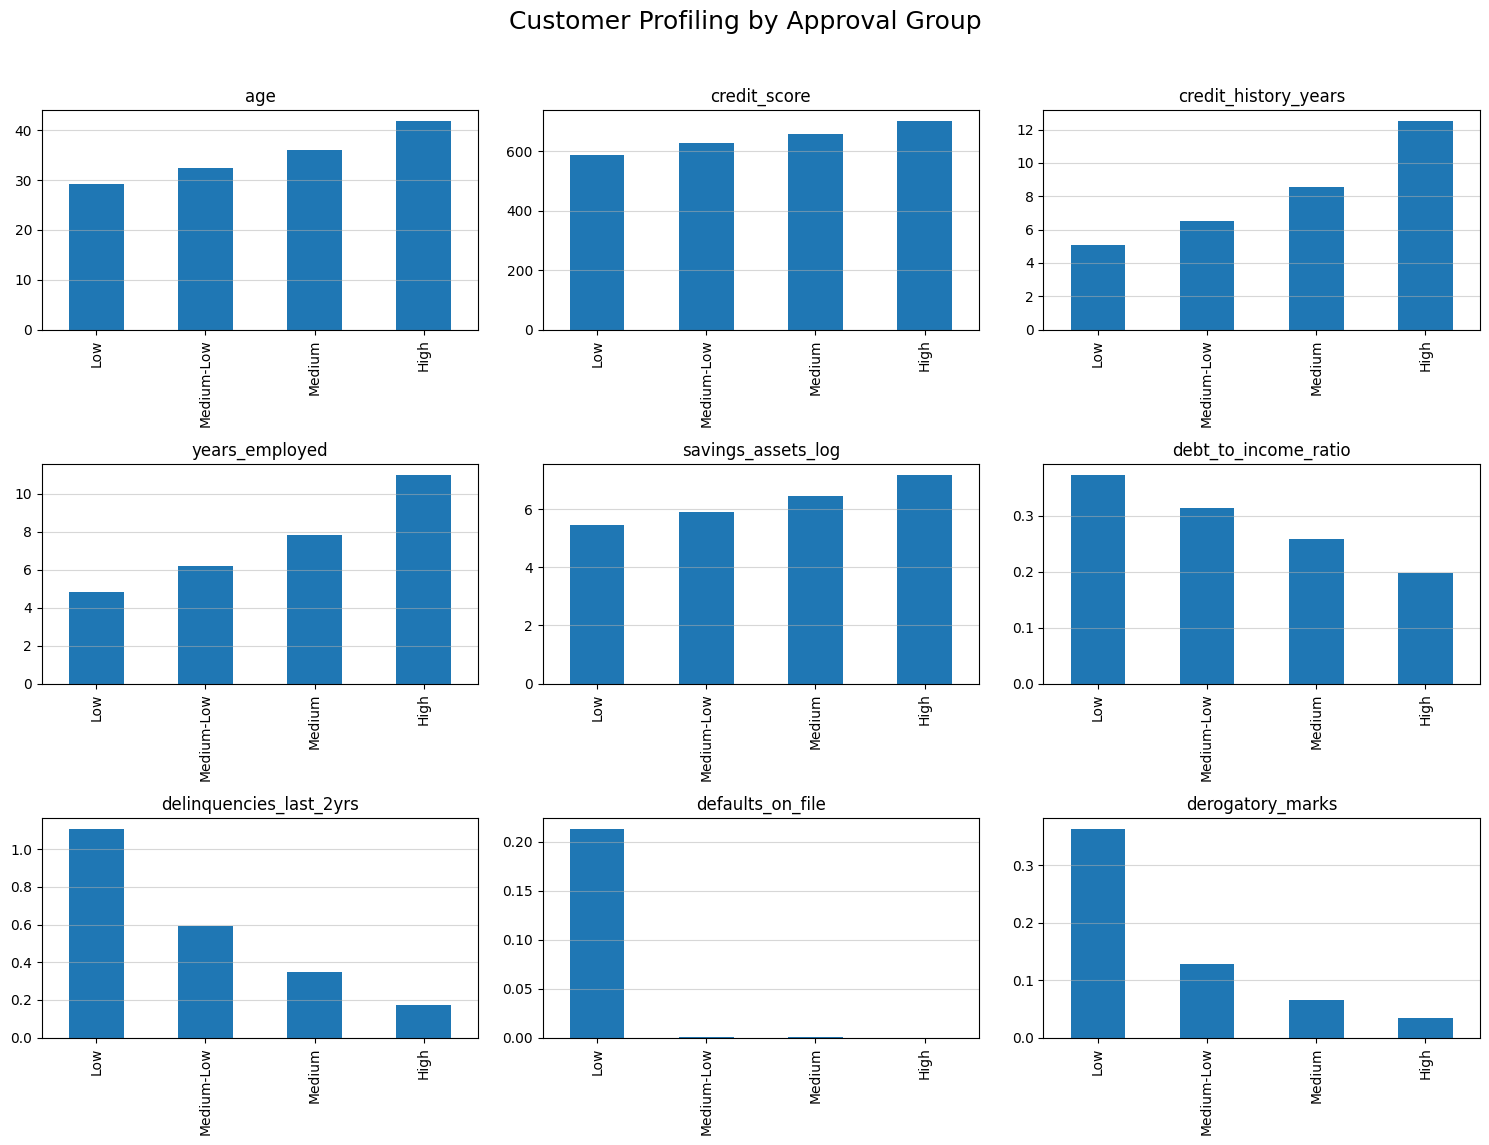

In [28]:
profiling_vars = [
    'age', 'credit_score', 'credit_history_years', 'years_employed',
    'savings_assets_log', 'debt_to_income_ratio',
    'delinquencies_last_2yrs', 'defaults_on_file', 'derogatory_marks'
]

group_means = df.groupby('approval_group')[profiling_vars].mean()

# --- Dynamic grid ---
n_vars = len(profiling_vars)
n_cols = 3                    
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(profiling_vars):
    group_means[var].plot(
        kind='bar',
        ax=axes[i]
    )
    axes[i].set_title(var)
    axes[i].set_xlabel("")
    axes[i].grid(axis='y', alpha=0.5)

# --- Tắt subplot thừa ---
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Customer Profiling by Approval Group", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

**Key Takeaways:**

**1. Approval rate tăng mạnh theo chất lượng hồ sơ tín dụng**

Có sự phân tầng rất rõ ràng giữa các nhóm khách hàng:
- Nhóm Low gần như không được phê duyệt (3.5%)
- Nhóm Medium-Low có tỷ lệ phê duyệt ở mức trung bình (38.6%)
- Nhóm Medium và High có xác suất được duyệt rất cao (80.3% và 97.8%)

**2. Credit score và credit history là trụ cột chính phân biệt các nhóm**
- Credit score tăng đều từ 586 → 703
- Credit history kéo dài từ ~5 năm → hơn 12 năm

=> Khách hàng được phê duyệt cao không chỉ có điểm tín dụng tốt, mà còn có lịch sử tín dụng dài và ổn định, phản ánh mức độ “đáng tin” theo thời gian.

**3. Sự ổn định nghề nghiệp là yếu tố hỗ trợ mạnh cho approval**
- Số năm làm việc tăng từ 4.8 → 11 năm
- Tuổi trung bình cũng tăng dần (29 → 42 tuổi)

=> Các nhóm có approval cao thường là khách hàng trưởng thành hơn, sự nghiệp ổn định, phù hợp với khẩu vị rủi ro của tổ chức tín dụng.

**4. Khả năng tài chính cải thiện rõ rệt ở các nhóm approval cao**
- Tài sản tiết kiệm (log) tăng đều (5.45 → 7.19)
- Debt-to-income ratio giảm mạnh (0.37 → 0.20)

=> Không chỉ kiếm được nhiều hơn, nhóm High còn quản lý nợ tốt hơn, tạo vùng đệm tài chính an toàn khi vay vốn.

**5. Hành vi tín dụng xấu gần như biến mất ở các nhóm tốt**
- Delinquencies, defaults, derogatory marks giảm mạnh và gần bằng 0 ở nhóm Medium & High
- Ngược lại, nhóm Low có:
  + 1 lần trễ hạn trung bình
  + Tỷ lệ default & derogatory khá cao

=> Chỉ cần một lịch sử tín dụng xấu nhỏ cũng đủ đẩy khách hàng xuống nhóm rủi ro thấp và làm sụt mạnh khả năng được duyệt.

##### ***b. Câu hỏi nghiên cứu 2: Với các kịch bản thay đổi kinh tế (thu nhập giảm, lãi tăng), tỷ lệ phê duyệt sẽ thay đổi thế nào?***

In [24]:
# FUNCTION TÍNH APPROVAL_RATE Ở RESEARCH QUESTION 1
def approval_rate(model, woe, X_Q1):
    X_woe = woe.transform(X_Q1)
    return model.predict_proba(X_woe)[:,1].mean()

In [25]:
np.random.seed(42)
sample_idx = np.random.choice(X_testQ1.index, 5000, replace=False)

X_base = X_testQ1.loc[sample_idx].copy()
meta = df.loc[sample_idx, [
    "credit_score", "debt_to_income_ratio"
]].copy()

base_rate = approval_rate(model, woe, X_base)
print(f"Baseline approval rate: {base_rate:.3f}")

Baseline approval rate: 0.555


**Kịch bản 1:** Income Shock (-20%)
- Segment 1: Giảm thu nhập → tăng loan_to_income → tăng rủi ro mạnh cho nhóm thu nhập thấp.
- Segment 2: Nhóm debt_to_income > 0.4 bị ảnh hưởng nặng nhất.

In [26]:
X_s1 = X_base.copy()

# Proxy income shock
X_s1["annual_income"] *= 0.8
X_s1["loan_to_income_ratio"] /= 0.8
X_s1["debt_to_income_ratio"] /= 0.8
X_s1["payment_to_income_ratio"] /= 0.8


s1_rate = approval_rate(model, woe, X_s1)

In [27]:
# Segment 1
low_income_mask = meta["credit_score"] < meta["credit_score"].quantile(0.3)

s1_low_income_rate = approval_rate(
    model, woe, X_s1.loc[low_income_mask])

In [28]:
# Segment 2
high_dti_mask = meta["debt_to_income_ratio"] > 0.4

s1_high_dti_rate = approval_rate(
    model, woe, X_s1.loc[high_dti_mask])

**Kịch bản 2:** Tăng lãi suất (+2%)
- Segment 3: Nhóm vay Personal Loan và Credit Card chịu ảnh hưởng nhiều nhất.
- Segment 4: Interest_rate tăng làm giảm approve rate mạnh ở nhóm credit_score < 620.

In [29]:
X_s2 = X_base.copy()

X_s2["interest_rate"] += 2.0

s2_rate = approval_rate(model, woe, X_s2)

In [30]:
# Segment 3
mask_personal_cc = X_base["product_type"].isin(["Personal Loan","Credit Card"])

s2_personal_cc_rate = approval_rate(model, woe, X_s2.loc[mask_personal_cc])

In [31]:
# Segment 4
low_cs_mask = meta["credit_score"] < 620

s2_low_cs_rate = approval_rate(
    model, woe, X_s2.loc[low_cs_mask])

**Kịch bản 3:** Combined Shock

In [32]:
X_s3 = X_base.copy()

X_s3["annual_income"] *= 0.8
X_s3["loan_to_income_ratio"] /= 0.8
X_s3["debt_to_income_ratio"] /= 0.8
X_s3["payment_to_income_ratio"] /= 0.8
X_s3["interest_rate"] += 2.0

s3_rate = approval_rate(model, woe, X_s3)

**TỔNG HỢP KẾT QUẢ**

In [33]:
results = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "S1: Income -20%",
        "S1: Low Income (proxy)",
        "S1: High DTI > 0.4",
        "S2: Interest +2% (proxy)",
        "S2: Personal Loan & Credit Card",
        "S2: Low Credit Score (<620)",
        "S3: Combined Shock"
    ],
    "Approval_Rate": [
        base_rate,
        s1_rate,
        s1_low_income_rate,
        s1_high_dti_rate,
        s2_rate,
        s2_personal_cc_rate,
        s2_low_cs_rate,
        s3_rate
    ]})

results["Δ vs Baseline (%)"] = (results["Approval_Rate"] - base_rate) * 100
results.round(3)

,Scenario,Approval_Rate,Δ vs Baseline (%)
0,Baseline,0.555,0.000
1,S1: Income -20%,0.484,-7.053
2,S1: Low Income (proxy),0.170,-38.460
3,S1: High DTI > 0.4,0.212,-34.228
4,S2: Interest +2% (proxy),0.460,-9.494
5,S2: Personal Loan & Credit Card,0.467,-8.801
6,S2: Low Credit Score (<620),0.168,-38.629
7,S3: Combined Shock,0.363,-19.149


##### ***c. Câu hỏi nghiên cứu 3: Những yếu tố tín dụng nào có ảnh hưởng lớn nhất đến quyết định phê duyệt?***

In [4]:
X_Q3 = df_Q3.drop(columns = 'loan_status')
y_Q3 = df_Q3['loan_status']

X_Q3 = pd.get_dummies(X_Q3, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_Q3, y_Q3, test_size = 0.2, random_state = 42)

In [5]:
X_Q3

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,...,payment_to_income_ratio,occupation_status_Self-Employed,occupation_status_Student,product_type_Line of Credit,product_type_Personal Loan,loan_intent_Debt Consolidation,loan_intent_Education,loan_intent_Home Improvement,loan_intent_Medical,loan_intent_Personal
0,40,17.2,25579,692,5.3,895,10820,0,0,0,...,0.008,False,False,False,False,False,False,False,False,False
1,33,7.3,43087,627,3.5,169,16550,0,1,0,...,0.412,False,False,False,True,False,False,True,False,False
2,42,1.1,20840,689,8.4,17,7852,0,0,0,...,0.034,False,True,False,False,True,False,False,False,False
3,53,0.5,29147,692,9.8,1480,11603,0,1,0,...,0.033,False,True,False,False,False,False,False,False,False
4,32,12.5,63657,630,7.2,209,12424,0,0,0,...,0.522,False,False,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,35,4.3,39449,570,16.3,1127,7576,0,0,0,...,0.362,False,False,False,False,False,True,False,False,False
49996,34,4.4,20496,672,12.6,1478,6276,1,0,0,...,0.062,False,False,False,False,False,False,False,False,True
49997,41,4.8,18743,719,10.1,17,10331,0,0,0,...,0.320,True,False,False,False,False,False,False,False,True
49998,38,0.4,17250,633,1.3,5,7779,0,0,1,...,0.027,False,True,False,True,False,False,False,False,True


**Sử dụng Random Forest để chọn ra biến phù hợp**

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
selector = SelectFromModel(rf, threshold = 'median')
selector.fit(X_train, y_train)

# Lấy mảng True/False đánh dấu các biến được chọn
selected_mask = selector.get_support()

# Trích xuất tên các cột được chọn từ X_train
selected_features = X_train.columns[selected_mask]

# In danh sách ra màn hình
print(f"Số lượng biến sau khi lọc: {len(selected_features)}")
print("\n--- DANH SÁCH CÁC BIẾN QUAN TRỌNG ĐƯỢC GIỮ LẠI ---")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

# Cập nhật lại tập dữ liệu với tên cột đầy đủ để dễ nhìn hơn
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

Số lượng biến sau khi lọc: 12

--- DANH SÁCH CÁC BIẾN QUAN TRỌNG ĐƯỢC GIỮ LẠI ---
1. age
2. years_employed
3. annual_income
4. credit_score
5. credit_history_years
6. current_debt
7. defaults_on_file
8. delinquencies_last_2yrs
9. interest_rate
10. debt_to_income_ratio
11. loan_to_income_ratio
12. payment_to_income_ratio


**Chạy mô hình bằng XGBoost**

In [7]:
xgb_model = XGBClassifier(
    n_estimators=200,      # Số lượng cây quyết định (có thể tăng lên 300, 500)
    learning_rate=0.1,     # Tốc độ học (nhỏ thì mô hình học kỹ hơn nhưng chậm)
    max_depth=5,           # Độ sâu tối đa của mỗi cây (giúp tránh học vẹt - overfitting)
    random_state=42,       # Đảm bảo kết quả giống nhau ở mỗi lần chạy
    eval_metric='logloss'  # Thước đo đánh giá mặc định
)

In [8]:
xgb_model.fit(X_train_selected, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [9]:
y_pre = xgb_model.predict(X_test_selected)
print(classification_report(y_test, y_pre))

              precision    recall  f1-score   support

           0       0.89      0.86      0.87      4509
           1       0.89      0.91      0.90      5491

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



**Model Tuning**

In [10]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 2. Khởi tạo XGBoost cơ bản
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# 3. Cài đặt bộ dò tìm (Thử ngẫu nhiên 10 tổ hợp để tiết kiệm thời gian)
random_search = RandomizedSearchCV(
    estimator=xgb_base, 
    param_distributions=param_grid, 
    n_iter=10,        # Số lần thử nghiệm (bạn có thể tăng lên 20 nếu máy mạnh)
    scoring='accuracy', # Mục tiêu tối ưu là Độ chính xác
    cv=3,             # Chia dữ liệu làm 3 phần để test chéo
    verbose=2,        # In tiến độ ra màn hình
    random_state=42,
    n_jobs=-1         # Dùng toàn bộ sức mạnh CPU của máy Mac
)

# 4. Bắt đầu quá trình Tuning (Bước này có thể mất vài phút)
print("Đang tiến hành Tuning XGBoost...")
random_search.fit(X_train_selected, y_train)

# 5. In ra bộ tham số "Đỉnh" nhất
print("\nTham số tốt nhất tìm được là:")
print(random_search.best_params_)

# 6. Dùng mô hình tốt nhất đó để dự báo luôn
best_xgb_model = random_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test_selected)

Đang tiến hành Tuning XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=300, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=300, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=300, subsample=1.0; 

In [11]:
final_xgb = XGBClassifier(
    max_depth=5,              # Thay bằng số bạn tìm được
    learning_rate=0.2,       # Thay bằng số bạn tìm được
    n_estimators=100,         # Thay bằng số bạn tìm được
    subsample=0.8,            # Thay bằng số bạn tìm được
    colsample_bytree=1.0       # Thay bằng số bạn tìm được
)

final_xgb.fit(X_train_selected, y_train)
y_pred_final = final_xgb.predict(X_test_selected)

**Model evaluation**

In [12]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88      4509
           1       0.89      0.91      0.90      5491

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



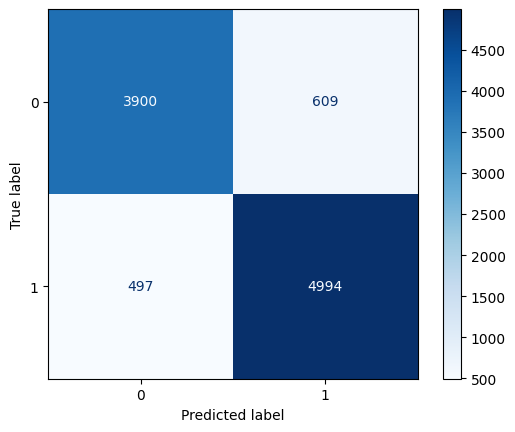

In [13]:
ConfusionMatrixDisplay.from_estimator(final_xgb, X_test_selected, y_test, cmap='Blues')

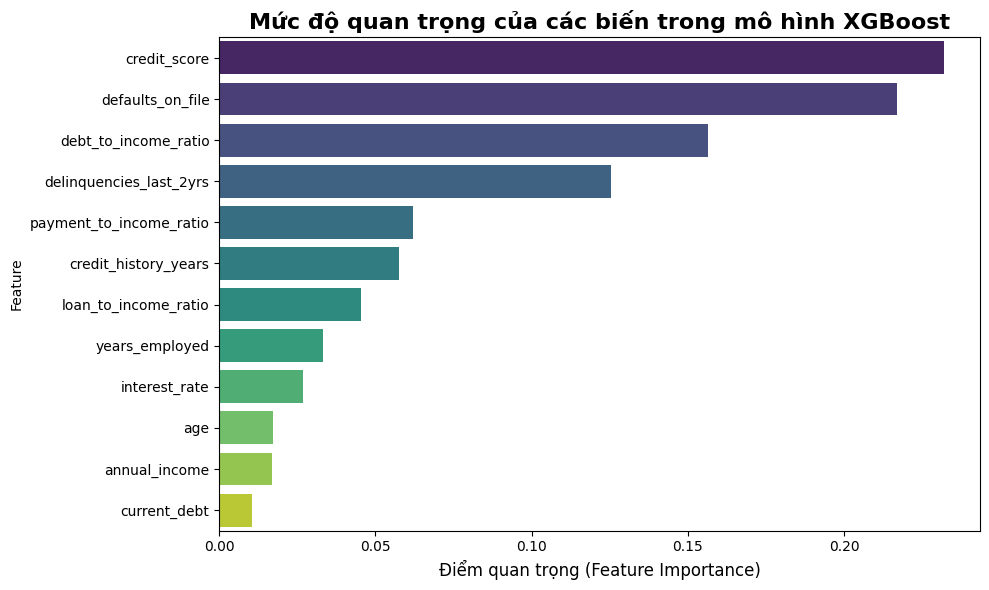

In [14]:
feats = final_xgb.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': selected_features, # Tên các biến đã lọc
    'Importance': feats
})

# 3. Sắp xếp giảm dần để biến quan trọng nhất nằm trên cùng
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Vẽ biểu đồ Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Mức độ quan trọng của các biến trong mô hình XGBoost', fontsize=16, fontweight='bold')
plt.xlabel('Điểm quan trọng (Feature Importance)', fontsize=12)
plt.tight_layout()
plt.show()


* Theo mô hình có thể thấy nguyên tố quan trọng nhất trong quyết định 1 khoản vay có được phê duyệt hay không chính là ```credit score```, điều này hoàn toàn hợp lý trong thực tế, để đánh giá một người có khả năng trả nợ được hay đúng hạn hay không hoàn toàn có thể dựa vào điểm tín dụng (credit score) của người đó
* Ngoài ra, yếu tố quan trọng thứ hai chính là ```defaults on file``` - người đó có bị vỡ nợ hay không để quyết định phê duyệt

# **THE END! ^^**